# Reflection-Based Summary Agent

A **summarizer chatbot** that uses the **reflection pattern** to iteratively improve a summary of an input document.

**Architecture diagram & design doc:** [README_REFLECTION_AGENT.md](../README_REFLECTION_AGENT.md)

---

## What This Example Demonstrates

| Component | Purpose |
|-----------|---------|
| **Reflection pattern** | Generate → Review → Revise loop — no tool use, just two LLM nodes critiquing each other |
| **SummaryAgent class** | Encapsulates graph, prompts, and memory in one reusable class |
| **Summarizer node** | Uses an LLM to generate/revise a summary of the input document |
| **Reviewer node** | Uses an LLM to critique the summary and provide improvement feedback |
| **Conditional edge** | `should_continue` caps the generate/review loop at N iterations |
| **MemorySaver** | Conversation memory per `thread_id` — user can ask follow-ups like "focus on specs" |

---

## How It Works

1. **User provides** a document to summarize
2. **Summarizer** generates a summary using an LLM
3. **Conditional edge** checks: have we reached the max iterations?
4. **Reviewer** critiques the summary and provides feedback
5. **Loop back** to Summarizer — it revises the summary incorporating the feedback
6. After N iterations, the refined summary is returned to the user

---

## Graph

```
START → summarizer → [should_continue?] → reviewer (yes) → summarizer
                                            → END (no — summary is ready)
```

## Setup Model

In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## Engineer Prompts for Reflection

Two system prompts drive the reflection loop:
- **Summarizer prompt** — tells the LLM to create a concise summary and incorporate feedback when available
- **Reviewer prompt** — tells the LLM to compare the summary against the original document and suggest improvements

In [2]:
SUMMARIZER_PROMPT = """\
You are a document summarizer who can summarize a document provided to you.
For the input provided, create a summary with less than 50 words.
If the user has provided critique, respond with a revised version of your \
previous attempts incorporating the feedback."""

REVIEWER_PROMPT = """\
You are a reviewer grading summaries for an article.
Compare the user input document and the generated summary.
Check if the summary accurately reflects the contents of the document.
Provide recommendations for improvement in less than 50 words."""

## Build the Summary-with-Review Agent

The `SummaryAgent` class encapsulates the full reflection graph:

- **`generate_summary`** node — calls the LLM with the summarizer prompt
- **`review_summary`** node — calls the LLM with the reviewer prompt
- **`should_continue`** conditional edge — checks if max iterations reached
- **`MemorySaver`** — enables multi-turn conversation memory

In [3]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage


class SummaryAgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]


class SummaryAgent:

    def __init__(self, model, summarizer_prompt, reviewer_prompt,
                 max_iterations=3, debug=False):
        self.model = model
        self.summarizer_prompt = summarizer_prompt
        self.reviewer_prompt = reviewer_prompt
        self.max_iterations = max_iterations
        self.debug = debug

        graph = StateGraph(SummaryAgentState)
        graph.add_node("summarizer", self.generate_summary)
        graph.add_node("reviewer", self.review_summary)

        graph.add_conditional_edges(
            "summarizer",
            self.should_continue,
            {True: "reviewer", False: END}
        )
        graph.add_edge("reviewer", "summarizer")
        graph.set_entry_point("summarizer")

        self.memory = MemorySaver()
        self.graph = graph.compile(checkpointer=self.memory)

    def generate_summary(self, state: SummaryAgentState):
        messages = [SystemMessage(content=self.summarizer_prompt)] + state["messages"]
        result = self.model.invoke(messages)

        if self.debug:
            print(f"{'=' * 50}\nSummarizer output:\n{result.content}\n")
        return {"messages": [result]}

    def review_summary(self, state: SummaryAgentState):
        messages = [SystemMessage(content=self.reviewer_prompt)] + state["messages"]
        result = self.model.invoke(messages)

        if self.debug:
            print(f"{'*' * 50}\nReviewer output:\n{result.content}\n")
        return {"messages": [result]}

    def should_continue(self, state: SummaryAgentState):
        total_iterations = len(state["messages"]) // 2

        if self.debug:
            print(f"Iteration: {total_iterations} / {self.max_iterations}")

        return total_iterations < self.max_iterations

## Visualize the Graph & Load Input Document

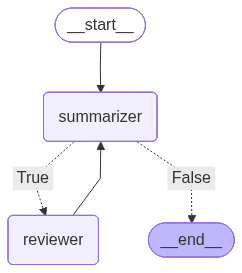

In [4]:
from IPython.display import Image

summary_chatbot = SummaryAgent(
    model,
    SUMMARIZER_PROMPT,
    REVIEWER_PROMPT,
    max_iterations=3,
    debug=True,
)

Image(summary_chatbot.graph.get_graph().draw_mermaid_png())

In [5]:
from pathlib import Path

spec_file = Path("../data/ecosprint_specification.txt")
source_content = spec_file.read_text().strip()

print(f"Input document ({len(source_content)} chars):\n")
print(source_content[:500] + "...")

Input document (2159 chars):

EcoSprint Specification Document

1. Overview

The EcoSprint is a revolutionary electric vehicle (EV) designed for efficiency and performance. With its sleek design and state-of-the-art technology, the EcoSprint appeals to environmentally conscious drivers who don't want to compromise on style or driving experience. Ideal for city driving and daily commutes, the EcoSprint offers a perfect blend of comfort, sustainability, and innovation.

2. Design Specifications

Exterior Design: The EcoSprint ...


## Execute the Reflection Loop (Debug Mode)

Watch the generate → review → revise cycle in action.  
The summarizer produces an initial summary, the reviewer critiques it, and the summarizer revises — repeating for 3 iterations.

In [6]:
import uuid

config = {"configurable": {"thread_id": str(uuid.uuid4())}}

messages = [HumanMessage(content=source_content)]
result = summary_chatbot.graph.invoke({"messages": messages}, config)

print("\n" + "=" * 60)
print("Final summary after reflection:")
print("=" * 60)
print(result["messages"][-1].content)

Summarizer output:
The EcoSprint is an innovative electric vehicle combining efficiency, performance, and style. It features a sleek design, spacious interior, powerful electric motor, and advanced technology, including a 10-inch infotainment system and driver assistance features, ensuring a safe and enjoyable driving experience with a range of up to 250 miles.

Iteration: 1 / 3
**************************************************
Reviewer output:
The summary accurately captures the key aspects of the EcoSprint, including its design, performance, technology, and safety features. However, it could benefit from mentioning specific design elements and color options. 

Recommendation: Include details about the exterior colors and interior luxury features for a more comprehensive overview.

Summarizer output:
The EcoSprint is an innovative electric vehicle that combines efficiency, performance, and style. It features a modern aerodynamic design available in colors like Midnight Black and Ocea

## Interactive Conversation with Follow-Up Feedback

The chatbot remembers context across turns.  
The user can ask for revisions like "focus more on the specifications" or "remove details about the touchscreen" — each triggers a fresh reflection loop while preserving conversation history.

In [7]:
summary_chatbot_quiet = SummaryAgent(
    model,
    SUMMARIZER_PROMPT,
    REVIEWER_PROMPT,
    max_iterations=3,
    debug=False,
)

user_inputs = [
    source_content,
    "Can you rewrite the summary by focusing more on the specifications?",
    "Can you remove details about the touchscreen?",
]

config = {"configurable": {"thread_id": "thread-summarizer"}}

for user_input in user_inputs:
    display = user_input[:80] + "..." if len(user_input) > 80 else user_input
    print(f"{'\u2500' * 40}\nUSER  : {display}")
    user_message = {"messages": [HumanMessage(content=user_input)]}
    ai_response = summary_chatbot_quiet.graph.invoke(user_message, config=config)
    print(f"AGENT : {ai_response['messages'][-1].content}\n")

────────────────────────────────────────
USER  : EcoSprint Specification Document

1. Overview

The EcoSprint is a revolutionary ...
AGENT : The EcoSprint is a cutting-edge electric vehicle that merges efficiency and style. It features a modern aerodynamic design in colors like Midnight Black and Ocean Blue, a luxurious interior with premium upholstery, a powerful electric motor, and advanced safety systems, offering a range of up to 250 miles.

────────────────────────────────────────
USER  : Can you rewrite the summary by focusing more on the specifications?
AGENT : The EcoSprint is a high-performance electric vehicle featuring a 200-horsepower motor, 50kWh battery with a 250-mile range, and 0-60 mph acceleration in 7.3 seconds. It includes a 10-inch infotainment system, advanced driver assistance features, and top safety ratings, all within a sleek, aerodynamic design.

────────────────────────────────────────
USER  : Can you remove details about the touchscreen?
AGENT : The EcoSpri